In [137]:
import matplotlib.pyplot as plt
import pandas as pd
import math, numpy as np
import re
import seaborn as sns

* relação cpu_time vs. wall_time: saber se ficou esperando;
* IPC (inst/cycles);
* branch_inst: quantidade de desvios (ifs, loops, etc);
* branch_miss: erros de previsão de branch;
* cache: tem artigo relacionando tempo de execução vs. l1 cache_miss
* TLB (translation lookaside buffer)
* page_faults: acesso à página não mapeada na RAM;


In [138]:
time_cache = '../data/outs/0321_C/all_time_cache.csv'
#ops = '../data/outs/0320/all_ops.csv'
mem = '../data/outs/0321_C/all_mem.csv'

try:
    df_tcache = pd.read_csv(time_cache, sep=' ')
    #df_ops = pd.read_csv(ops, sep=' ')
    df_mem = pd.read_csv(mem, sep=' ')
    print("Dados lidos com sucesso!")

except FileNotFoundError:
    print(f"Erro: Arquivo não encontrado!")

Dados lidos com sucesso!


In [139]:
df_tcache.dtypes

nome           object
n               int64
m               int64
c               int64
fila           object
cpu_time        int64
wall_time       int64
l1_miss         int64
l2_ref          int64
llc_miss        int64
cycles          int64
inst            int64
dtlb            int64
page_faults     int64
branch_inst     int64
branch_miss     int64
dtype: object

In [140]:
df_mem.dtypes

nome    object
n        int64
m        int64
c        int64
fila    object
mem      int64
dtype: object

In [141]:
#df_ops.dtypes

In [142]:
#df_ops = df_ops.drop('Unnamed: 8', axis=1)

# Uso de memória

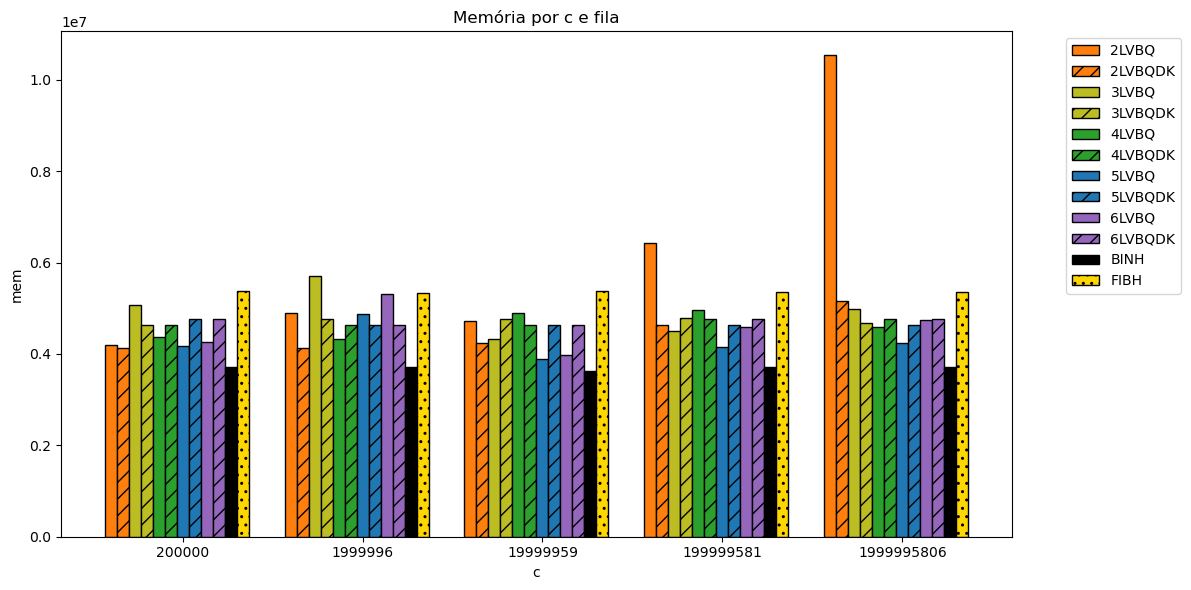

In [143]:
pivot = df_mem.pivot_table(
    index="c",
    columns="fila",
    values="mem",
    aggfunc="first"
)

c_vals = pivot.index.to_list()
filas = pivot.columns.to_list()

x = np.arange(len(c_vals))
width = 0.8 / len(filas)

# 🎨 cores por número da fila (LVBQ)
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(12, 6))

for i, fila in enumerate(filas):

    # ===== HEAPS (cores exclusivas) =====
    if "BINH" in fila:
        color = "black"
        hatch = "xx"
        
    elif "FIBH" in fila:
        color = "gold"
        hatch = ".."

    # ===== LVBQ / LVBQDK =====
    else:
        # extrai número da fila (1–6)
        m = re.match(r"\d+", fila)
        num = m.group() if m else None

        color = colors.get(num, "tab:gray")

        # padrão para DK
        hatch = "//" if "LVBQDK" in fila else None

    plt.bar(
        x + i * width,
        pivot[fila].values,
        width,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

plt.xticks(x + width * len(filas) / 2, c_vals)
plt.xlabel("c")
plt.ylabel("mem")
plt.title("Memória por c e fila")
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

In [144]:
rank = (
    df_mem
    .sort_values(['nome', 'mem'])
    .groupby('nome')
    .head(6)
)

rank['rank'] = rank.groupby('nome').cumcount() + 1

resultado = rank.pivot(
    index='nome',
    columns='rank',
    values=['fila', 'mem']
)

resultado.columns = [f'{col}{rank}' for col, rank in resultado.columns]

resultado = resultado.reset_index()

resultado = resultado.sort_values('mem1')

resultado

,nome,fila1,fila2,fila3,fila4,fila5,fila6,mem1,mem2,mem3,mem4,mem5,mem6
2,GEN7,BINH,5LVBQ,6LVBQ,2LVBQDK,3LVBQ,4LVBQDK,3629056,3891200,3981312,4231168,4321280,4628480
4,GEN9,BINH,5LVBQ,4LVBQ,5LVBQDK,3LVBQDK,6LVBQ,3710976,4235264,4595712,4628480,4677632,4747264
3,GEN8,BINH,5LVBQ,3LVBQ,6LVBQ,2LVBQDK,5LVBQDK,3715072,4153344,4497408,4591616,4624384,4632576
0,GEN5,BINH,2LVBQDK,5LVBQ,2LVBQ,6LVBQ,4LVBQ,3719168,4120576,4169728,4190208,4268032,4374528
1,GEN6,BINH,2LVBQDK,4LVBQ,4LVBQDK,5LVBQDK,6LVBQDK,3719168,4136960,4317184,4636672,4636672,4636672


# Operações

In [145]:
def custo_teorico(row):
    n = row["n"]
    C = row["c"]
    ext = row["extractMin"]
    ins = row["insert"]
    dk  = row["dk"]
    fila = row["fila"]

    # ===== BINH =====
    if fila == "BINH":
        logn = np.log2(n)
        return (ext + ins + dk) * logn

    # ===== FIBH =====
    if fila == "FIBH":
        logn = np.log2(n)
        return ext * logn + ins + dk

    # ===== BUCKETS =====
    m = re.match(r"(\d+)LVBQ", fila)
    if m:
        k = int(m.group(1))

        # custo de extract
        if k == 1:
            cost_ext = C
        else:
            cost_ext = C ** (1 / k)

        return ext * cost_ext + ins + dk

    return np.nan

In [146]:
# # Quais ops dominam
# df_ops["total_ops"] = df_ops["extractMin"] + df_ops["insert"] + df_ops["dk"]
# df_ops["p_exM"] = df_ops["extractMin"] / df_ops["total_ops"]
# df_ops["p_insert"] = df_ops["insert"] / df_ops["total_ops"]
# df_ops["p_dk"] = df_ops["dk"] / df_ops["total_ops"]
# df_ops["usa_dk"] = df_ops["fila"].str.contains("DK") | (df_ops["fila"] == "FIBH")
# df_ops

In [147]:
#df_ops["custo_teorico"] = df_ops.apply(custo_teorico, axis=1)

In [148]:
# totais = df_ops.groupby("usa_dk")["custo_teorico"].sum()
# print(totais)
# perc = (totais[False] - totais[True]) / totais[True] * 100
# print(perc, "% mais custo sem DK")

# Tempo de execução

In [149]:
df_tcache.head()

,nome,n,m,c,fila,cpu_time,wall_time,l1_miss,l2_ref,llc_miss,cycles,inst,dtlb,page_faults,branch_inst,branch_miss
0,GEN5,100000,500000,200000,1LVBQ,62,62,2696445,4133094,246885,255252611,426347850,300700,2505,62279355,470794
1,GEN5,100000,500000,200000,1LVBQ,63,63,3377456,5048873,250243,263647719,434953257,332550,1537,63952126,540976
2,GEN5,100000,500000,200000,1LVBQ,61,61,2771365,4248998,248532,253714053,426938663,304683,1533,62533740,465782
3,GEN5,100000,500000,200000,1LVBQ,59,59,2864447,4337572,242929,252065709,426937152,303104,0,62532239,463274
4,GEN5,100000,500000,200000,1LVBQ,59,59,2846061,4329030,240160,250452497,426937367,304335,272,62532490,462829


In [150]:
df_time = df_tcache[
    ['nome', 'n', 'c', 'fila', 'cpu_time', 'wall_time']
].copy()
df_time

,nome,n,c,fila,cpu_time,wall_time
0,GEN5,100000,200000,1LVBQ,62,62
1,GEN5,100000,200000,1LVBQ,63,63
2,GEN5,100000,200000,1LVBQ,61,61
3,GEN5,100000,200000,1LVBQ,59,59
4,GEN5,100000,200000,1LVBQ,59,59
...,...,...,...,...,...,...
675,GEN9,100000,1999995806,FIBH,108,108
676,GEN9,100000,1999995806,FIBH,108,108
677,GEN9,100000,1999995806,FIBH,109,109
678,GEN9,100000,1999995806,FIBH,108,108


In [151]:
df_time["wall_cpu_ratio"] = df_time["wall_time"] / df_time["cpu_time"]
print("Min ratio", df_time["wall_cpu_ratio"].min())
print("Max ratio", df_time["wall_cpu_ratio"].max())

Min ratio 1.0
Max ratio 3.151572252973737


Logo, CPU Bound

In [152]:
df_cpu = df_tcache[
    ['nome', 'n', 'c', 'fila', 'cpu_time']
].copy()
df_cpu = (
    df_cpu.groupby(['nome', 'fila'], as_index=False)
      .agg(
           cpu_mean=('cpu_time', 'mean'),
           cpu_std =('cpu_time', 'std'),
           cpu_var =('cpu_time', 'var'),
           c=('c', 'first'),
      )
)
df_cpu['cpu_cv'] = df_cpu['cpu_std'] / df_cpu['cpu_mean']
df_cpu

,nome,fila,cpu_mean,cpu_std,cpu_var,c,cpu_cv
0,GEN5,1LVBQ,60.8,1.475730,2.177778,200000,0.024272
1,GEN5,1LVBQDK,36.2,0.421637,0.177778,200000,0.011647
2,GEN5,2LVBQ,42.3,0.674949,0.455556,200000,0.015956
3,GEN5,2LVBQDK,36.2,1.229273,1.511111,200000,0.033958
4,GEN5,3LVBQ,41.2,1.398412,1.955556,200000,0.033942
...,...,...,...,...,...,...,...
63,GEN9,5LVBQDK,66.6,0.699206,0.488889,1999995806,0.010499
64,GEN9,6LVBQ,127.7,0.823273,0.677778,1999995806,0.006447
65,GEN9,6LVBQDK,62.1,0.737865,0.544444,1999995806,0.011882
66,GEN9,BINH,86.3,0.483046,0.233333,1999995806,0.005597


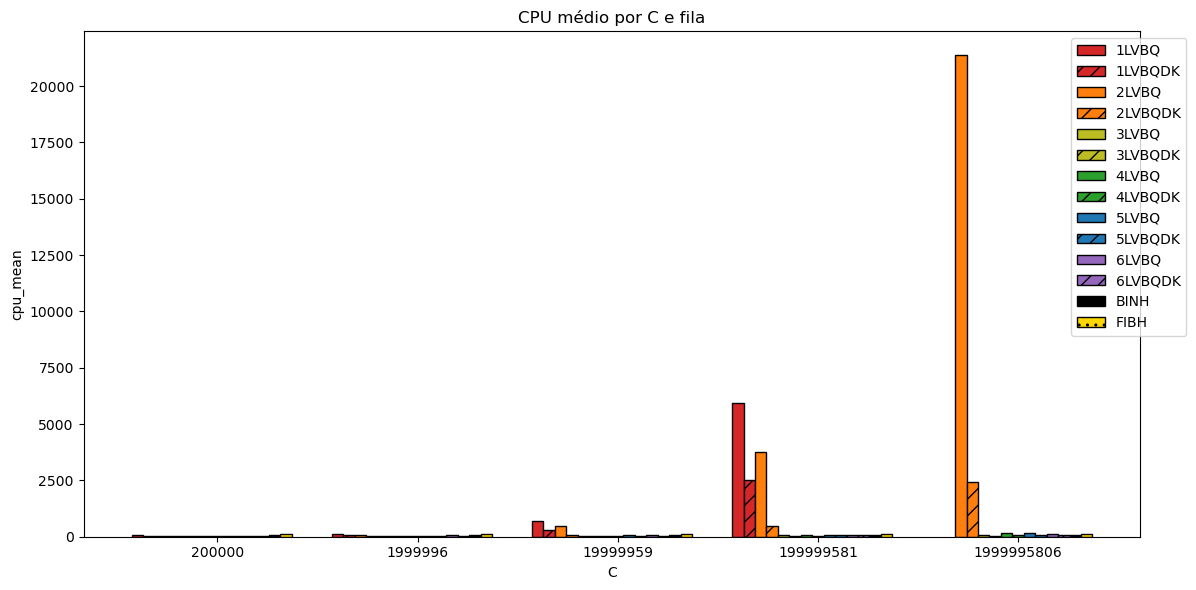

In [153]:
pivot = df_cpu.pivot_table(
    index="c",
    columns="fila",
    values="cpu_mean",
    aggfunc="first"
)

n_vals = pivot.index.to_list()
filas = pivot.columns.to_list()

x = np.arange(len(n_vals))
width = 0.8 / len(filas)

# 🎨 cores por número da fila (LVBQ)
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(12, 6))

for i, fila in enumerate(filas):

    # ===== HEAPS (se existirem) =====
    if "BINH" in fila:
        color = "black"
        hatch = "xx"
        
    elif "FIBH" in fila:
        color = "gold"
        hatch = ".."

    # ===== LVBQ / LVBQDK =====
    else:
        m = re.match(r"\d+", fila)
        num = m.group() if m else None

        color = colors.get(num, "tab:gray")

        # DK com padrão
        hatch = "//" if "LVBQDK" in fila else None

    plt.bar(
        x + i * width,
        pivot[fila].values,
        width,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

plt.xticks(x + width * len(filas) / 2, n_vals)
plt.xlabel("C")
plt.ylabel("cpu_mean")
plt.title("CPU médio por C e fila")
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

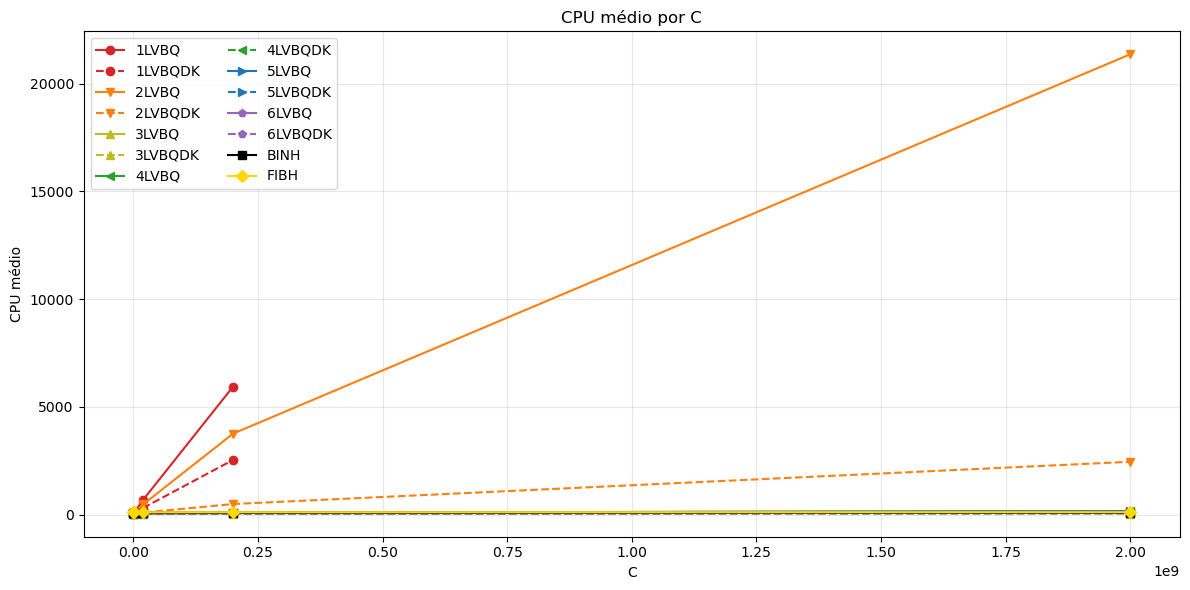

In [154]:

# selecionar BINH, Fibonacci e todas LVBQ (1–6) com ou sem DK
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQ(DK)?"))
)

df_sel = df_cpu[mask].copy()

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("c")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ / LVBQDK =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        # DK → tracejado
        linestyle = "--" if "DK" in fila else "-"

        # marcador por nível
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["c"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("C")
plt.ylabel("CPU médio")
plt.title("CPU médio por C")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

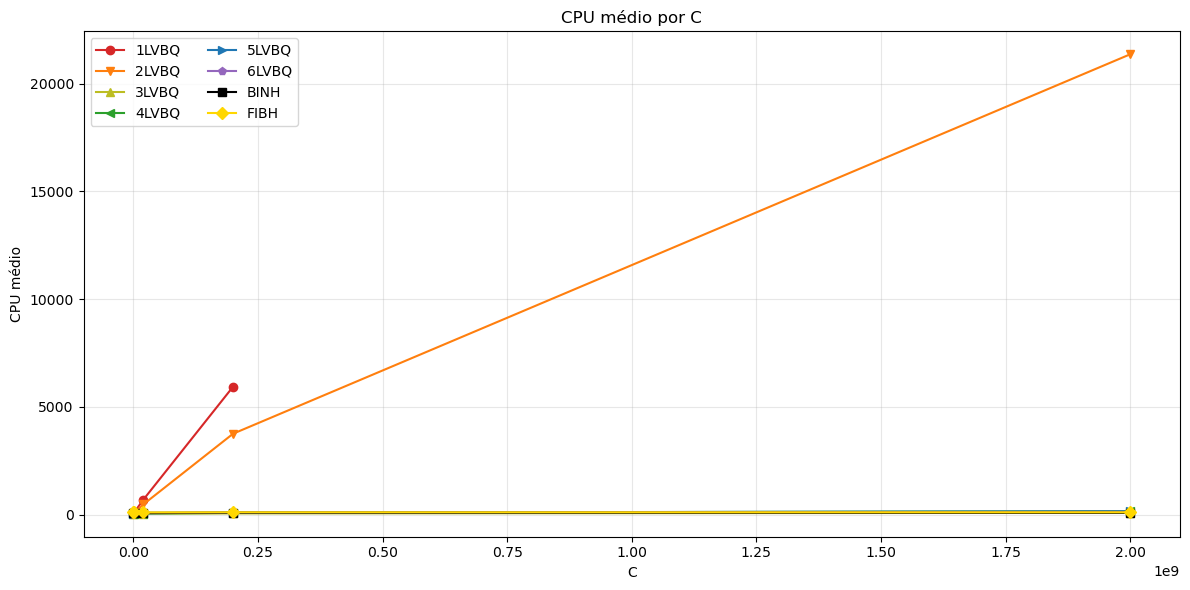

In [155]:
# 🎯 selecionar BINH, Fibonacci e todas LVBQ (1–6) **sem DK**
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQ$"))  # somente LVBQ sem DK
)

df_sel = df_cpu[mask].copy()

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("c")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ simples (1–6) =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        linestyle = "-"  # todas LVBQ simples são sólidas
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["c"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("C")
plt.ylabel("CPU médio")
plt.title("CPU médio por C")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

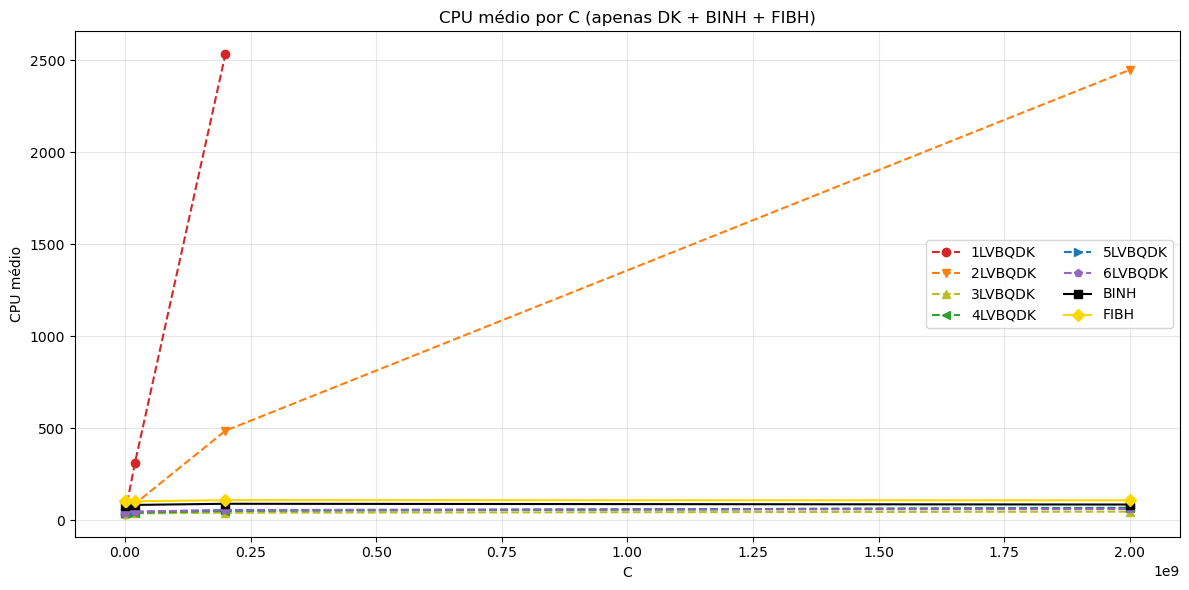

In [156]:
# 🎯 selecionar BINH, Fibonacci e todas LVBQ (1–6) **apenas DK**
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQDK$"))  # somente LVBQ DK
)

df_sel = df_cpu[mask].copy()

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("c")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ DK (1–6) =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        linestyle = "--"  # DK → tracejado
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["c"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("C")
plt.ylabel("CPU médio")
plt.title("CPU médio por C (apenas DK + BINH + FIBH)")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Outras métricas

In [157]:
df_tcache.head(10)

,nome,n,m,c,fila,cpu_time,wall_time,l1_miss,l2_ref,llc_miss,cycles,inst,dtlb,page_faults,branch_inst,branch_miss
0,GEN5,100000,500000,200000,1LVBQ,62,62,2696445,4133094,246885,255252611,426347850,300700,2505,62279355,470794
1,GEN5,100000,500000,200000,1LVBQ,63,63,3377456,5048873,250243,263647719,434953257,332550,1537,63952126,540976
2,GEN5,100000,500000,200000,1LVBQ,61,61,2771365,4248998,248532,253714053,426938663,304683,1533,62533740,465782
3,GEN5,100000,500000,200000,1LVBQ,59,59,2864447,4337572,242929,252065709,426937152,303104,0,62532239,463274
4,GEN5,100000,500000,200000,1LVBQ,59,59,2846061,4329030,240160,250452497,426937367,304335,272,62532490,462829
5,GEN5,100000,500000,200000,1LVBQ,60,60,2764452,4263624,243036,253520331,426939376,303458,1699,62534102,465789
6,GEN5,100000,500000,200000,1LVBQ,60,60,2769080,4264396,244600,252481050,426939034,303027,1536,62533888,464673
7,GEN5,100000,500000,200000,1LVBQ,63,63,2761553,4226809,265944,260764574,426939872,303878,1699,62534214,464866
8,GEN5,100000,500000,200000,1LVBQ,60,60,2768217,4262756,245421,253012793,426939055,302362,1536,62533872,464089
9,GEN5,100000,500000,200000,1LVBQ,61,61,2764266,4269586,248638,254023068,426939214,305193,1699,62534060,464788


In [158]:
df_tcache['ipc'] = df_tcache['inst'] / df_tcache['cycles']

### Eficiência de Cache

In [159]:
# normalizar
df_cache = df_tcache[
    ['nome', 'fila', 'inst', 'l1_miss', 'llc_miss']
].copy()

inst_safe = df_cache["inst"].replace(0, np.nan)

df_cache["l1_pi"]  = df_cache["l1_miss"]  / inst_safe
df_cache["llc_pi"] = df_cache["llc_miss"] / inst_safe


# agregar
df_cache = (
    df_cache.groupby(['nome', 'fila'], as_index=False)
      .agg(
           l1_mean=('l1_pi', 'mean'),
           l1_std =('l1_pi', 'std'),
           l1_var =('l1_pi', 'var'),
           llc_mean=('llc_pi', 'mean'),
           llc_std =('llc_pi', 'std'),
           llc_var =('llc_pi', 'var'),
      )
)

df_cache['l1_cv']  = df_cache['l1_std']  / df_cache['l1_mean']
df_cache['llc_cv'] = df_cache['llc_std'] / df_cache['llc_mean']

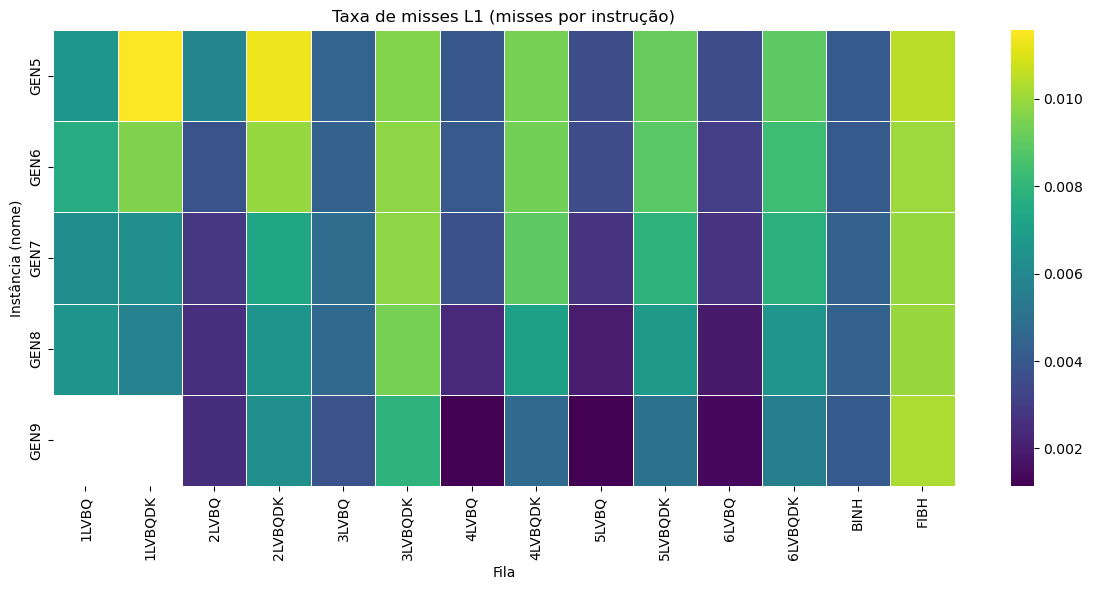

In [160]:

# ===== métrica escolhida =====
df_plot = df_cache.copy()

# opção A: L1 apenas
df_plot["miss"] = df_plot["l1_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="miss")
heat = heat.sort_index().sort_index(axis=1)

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Taxa de misses L1 (misses por instrução)")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

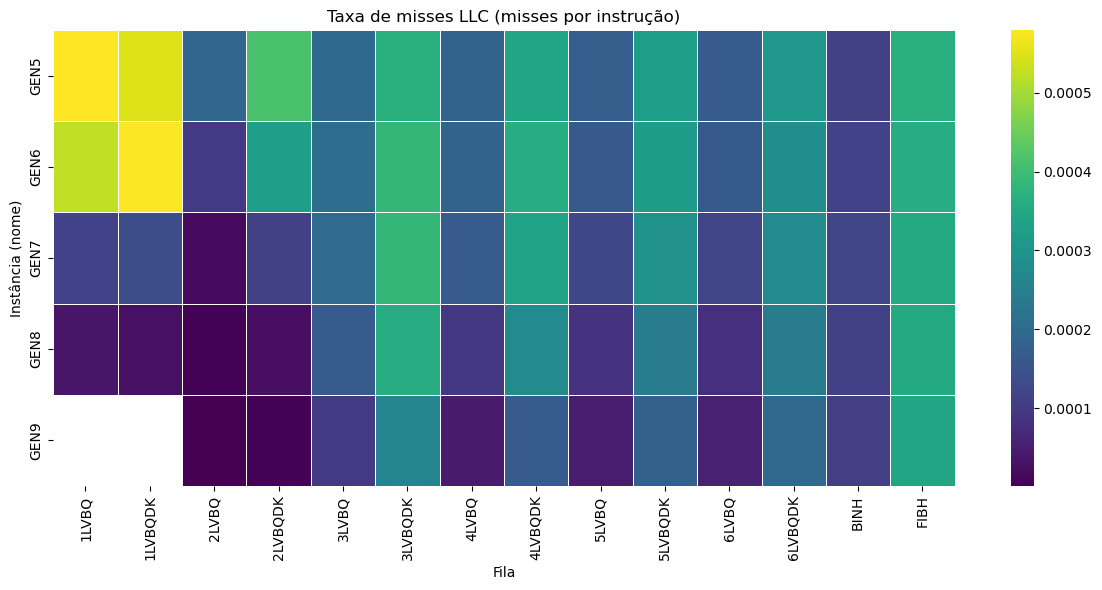

In [161]:

# ===== métrica escolhida =====
df_plot = df_cache.copy()

# opção A: L1 apenas
df_plot["miss"] = df_plot["llc_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="miss")
heat = heat.sort_index().sort_index(axis=1)

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Taxa de misses LLC (misses por instrução)")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

### Instruções e cíclos

In [162]:
df_instc = df_tcache[
    ['nome', 'fila', 'inst', 'cycles']
].copy()

df_instc = (
    df_instc.groupby(['nome', 'fila'], as_index=False)
      .agg(
           inst_total=('inst', 'sum'),
           cycles_total=('cycles', 'sum'),
      )
)

df_instc['ipc'] = (
    df_instc['inst_total'] /
    df_instc['cycles_total'].replace(0, np.nan)
)

df_instc

,nome,fila,inst_total,cycles_total,ipc
0,GEN5,1LVBQ,4276810840,2548934405,1.677882
1,GEN5,1LVBQDK,2355642458,1575650260,1.495029
2,GEN5,2LVBQ,4219509008,1917463046,2.200569
3,GEN5,2LVBQDK,2575706046,1601375914,1.608433
4,GEN5,3LVBQ,4215279174,1847522991,2.281584
...,...,...,...,...,...
63,GEN9,5LVBQDK,6108744689,2924078166,2.089118
64,GEN9,6LVBQ,15435313569,5387441461,2.865055
65,GEN9,6LVBQDK,5459345984,2706668222,2.016999
66,GEN9,BINH,7731306810,3694569220,2.092614


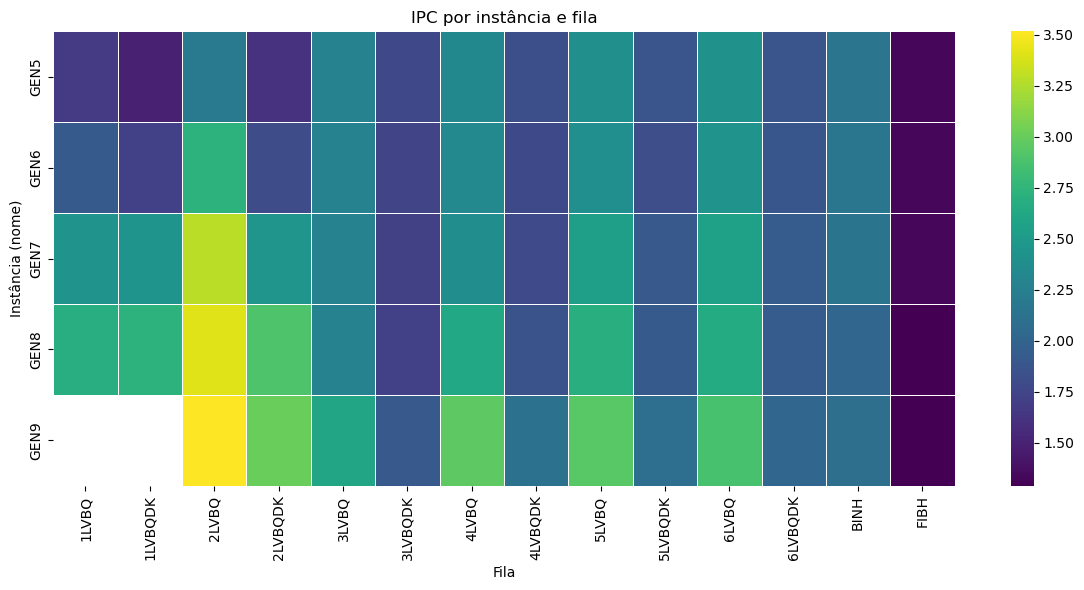

In [163]:

# ===== métrica escolhida =====
df_plot = df_instc.copy()

# opção A: LLC apenas
df_plot["miss"] = df_plot["ipc"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="ipc")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("IPC por instância e fila")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

In [164]:
df_inst = df_tcache[
    ['nome', 'fila', 'inst']
].copy()

df_inst = (
    df_inst.groupby(['nome', 'fila'], as_index=False)
      .agg(
           inst_total=('inst', 'sum'),
           inst_mean=('inst', 'mean'),
           inst_std =('inst', 'std'),
      )
)

df_inst['inst_cv'] = df_inst['inst_std'] / df_inst['inst_mean']
df_inst

,nome,fila,inst_total,inst_mean,inst_std,inst_cv
0,GEN5,1LVBQ,4276810840,4.276811e+08,2.561920e+06,5.990257e-03
1,GEN5,1LVBQDK,2355642458,2.355642e+08,1.304580e+02,5.538107e-07
2,GEN5,2LVBQ,4219509008,4.219509e+08,3.268058e+05,7.745115e-04
3,GEN5,2LVBQDK,2575706046,2.575706e+08,2.419620e+02,9.394006e-07
4,GEN5,3LVBQ,4215279174,4.215279e+08,2.236424e+04,5.305517e-05
...,...,...,...,...,...,...
63,GEN9,5LVBQDK,6108744689,6.108745e+08,7.879714e+01,1.289907e-07
64,GEN9,6LVBQ,15435313569,1.543531e+09,2.557962e+03,1.657214e-06
65,GEN9,6LVBQDK,5459345984,5.459346e+08,1.486444e+02,2.722751e-07
66,GEN9,BINH,7731306810,7.731307e+08,2.230232e+02,2.884676e-07


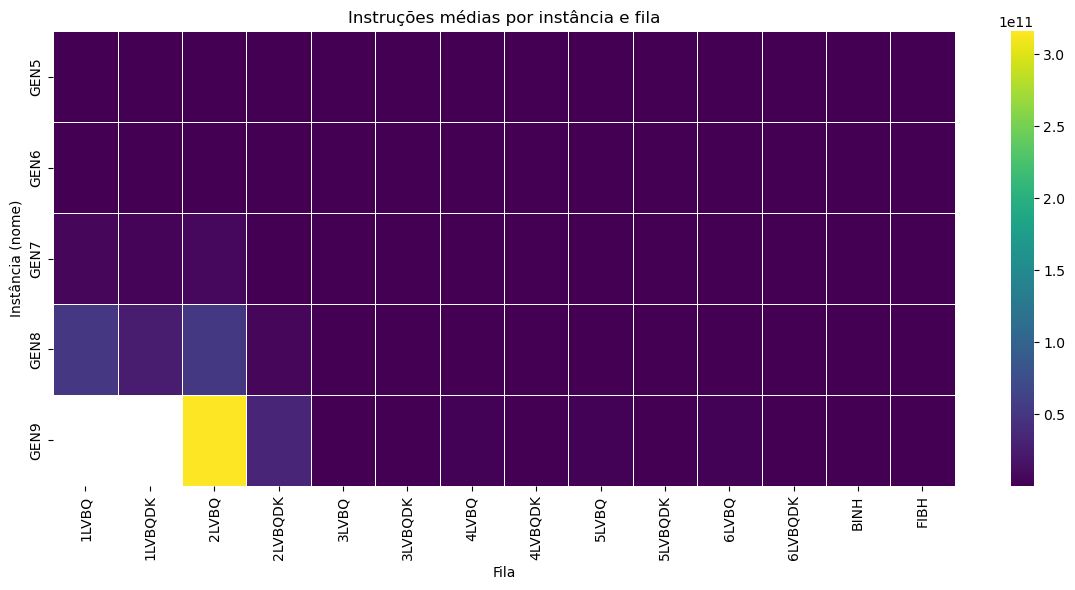

In [165]:

# ===== métrica escolhida =====
df_plot = df_inst.copy()

# opção A: LLC apenas
df_plot["miss"] = df_plot["inst_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="inst_mean")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Instruções médias por instância e fila")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

### Page fault

In [166]:
# normalizar
df_pf = df_tcache[
    ['nome', 'fila', 'inst', 'page_faults']
].copy()

inst_safe = df_pf["inst"].replace(0, np.nan)

df_pf["pf_pi"] = df_pf["page_faults"] / inst_safe

# agregar
df_pf = (
    df_pf.groupby(['nome', 'fila'], as_index=False)
      .agg(
           pf_mean=('pf_pi', 'mean'),
           pf_std =('pf_pi', 'std'),
           pf_var =('pf_pi', 'var'),
      )
)

df_pf['pf_cv'] = df_pf['pf_std'] / df_pf['pf_mean']
df_pf

,nome,fila,pf_mean,pf_std,pf_var,pf_cv
0,GEN5,1LVBQ,3.277084e-06,1.709789e-06,2.923378e-12,0.521741
1,GEN5,1LVBQDK,0.000000e+00,0.000000e+00,0.000000e+00,NaN
2,GEN5,2LVBQ,0.000000e+00,0.000000e+00,0.000000e+00,NaN
3,GEN5,2LVBQDK,0.000000e+00,0.000000e+00,0.000000e+00,NaN
4,GEN5,3LVBQ,7.115895e-10,2.250243e-09,5.063596e-18,3.162278
...,...,...,...,...,...,...
63,GEN9,5LVBQDK,0.000000e+00,0.000000e+00,0.000000e+00,NaN
64,GEN9,6LVBQ,0.000000e+00,0.000000e+00,0.000000e+00,NaN
65,GEN9,6LVBQDK,0.000000e+00,0.000000e+00,0.000000e+00,NaN
66,GEN9,BINH,0.000000e+00,0.000000e+00,0.000000e+00,NaN


In [167]:
# normalizar
df_dtlb = df_tcache[
    ['nome', 'fila', 'inst', 'dtlb']
].copy()

inst_safe = df_dtlb["inst"].replace(0, np.nan)

df_dtlb["dtlb_pi"] = df_dtlb["dtlb"] / inst_safe

# agregar
df_dtlb = (
    df_dtlb.groupby(['nome', 'fila'], as_index=False)
      .agg(
           dtlb_mean=('dtlb_pi', 'mean'),
           dtlb_std=('dtlb_pi', 'std'),
           dtlb_var=('dtlb_pi', 'var'),
      )
)

df_dtlb['dtlb_cv'] = df_dtlb['dtlb_std'] / df_dtlb['dtlb_mean']
df_dtlb

,nome,fila,dtlb_mean,dtlb_std,dtlb_var,dtlb_cv
0,GEN5,1LVBQ,0.000716,1.722822e-05,2.968114e-10,0.024056
1,GEN5,1LVBQDK,0.000613,7.995883e-06,6.393414e-11,0.013038
2,GEN5,2LVBQ,0.000291,1.083955e-05,1.174959e-10,0.037305
3,GEN5,2LVBQDK,0.000450,5.081822e-06,2.582492e-11,0.011301
4,GEN5,3LVBQ,0.000213,3.426325e-06,1.173970e-11,0.016049
...,...,...,...,...,...,...
63,GEN9,5LVBQDK,0.000203,3.685546e-06,1.358325e-11,0.018123
64,GEN9,6LVBQ,0.000063,6.403889e-07,4.100980e-13,0.010116
65,GEN9,6LVBQDK,0.000230,3.550843e-06,1.260849e-11,0.015434
66,GEN9,BINH,0.000134,2.743400e-06,7.526241e-12,0.020411


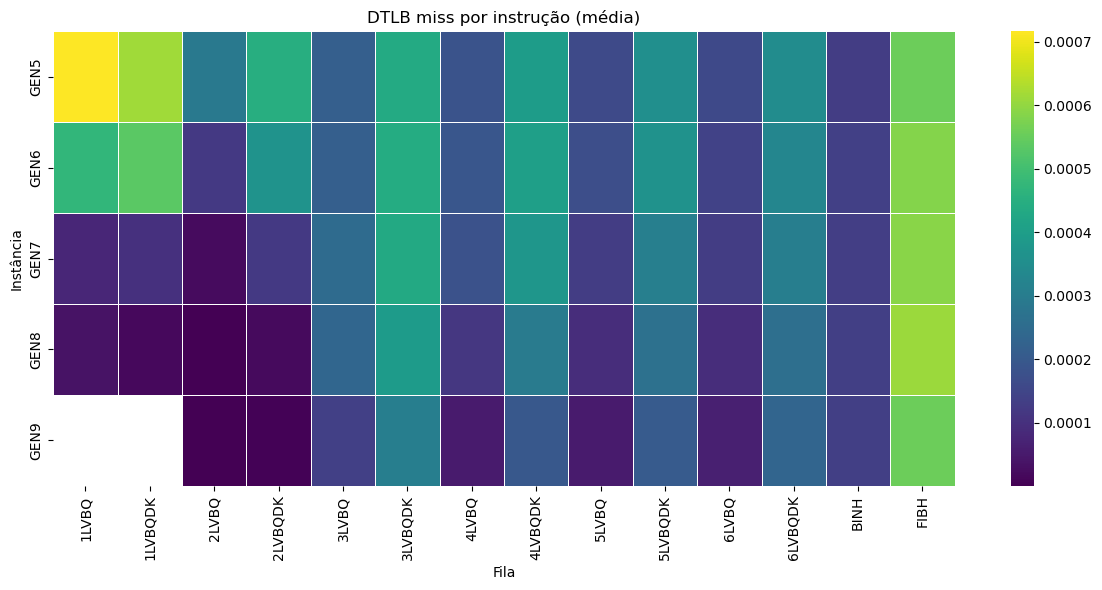

In [168]:
# ===== métrica escolhida =====
df_plot = df_dtlb.copy()

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="dtlb_mean")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("DTLB miss por instrução (média)")
plt.xlabel("Fila")
plt.ylabel("Instância")

plt.tight_layout()
plt.show()

### Branch

In [169]:
# normalizar
df_branches = df_tcache[
    ['nome', 'fila', 'branch_miss', 'branch_inst']
].copy()
inst_safe = df_branches["branch_inst"].replace(0, np.nan)
df_branches['bm_rate'] = df_branches['branch_miss'] / inst_safe

# agregar
df_branches = (
    df_branches.groupby(['nome', 'fila'], as_index=False)
      .agg(
           bm_mean=('bm_rate', 'mean'),
           bm_std =('bm_rate', 'std'),
           bm_var =('bm_rate', 'var'),
      )
)
df_branches['bm_cv'] = df_branches['bm_std'] / df_branches['bm_mean']
df_branches

,nome,fila,bm_mean,bm_std,bm_var,bm_cv
0,GEN5,1LVBQ,0.007544,0.000324,1.052146e-07,0.042995
1,GEN5,1LVBQDK,0.013263,0.000028,7.783507e-10,0.002104
2,GEN5,2LVBQ,0.006324,0.000009,7.298556e-11,0.001351
3,GEN5,2LVBQDK,0.012420,0.000147,2.155574e-08,0.011821
4,GEN5,3LVBQ,0.004518,0.000010,1.008548e-10,0.002223
...,...,...,...,...,...,...
63,GEN9,5LVBQDK,0.010879,0.000043,1.859982e-09,0.003964
64,GEN9,6LVBQ,0.003125,0.000008,6.736242e-11,0.002627
65,GEN9,6LVBQDK,0.012513,0.000028,8.096424e-10,0.002274
66,GEN9,BINH,0.016183,0.000010,9.399020e-11,0.000599


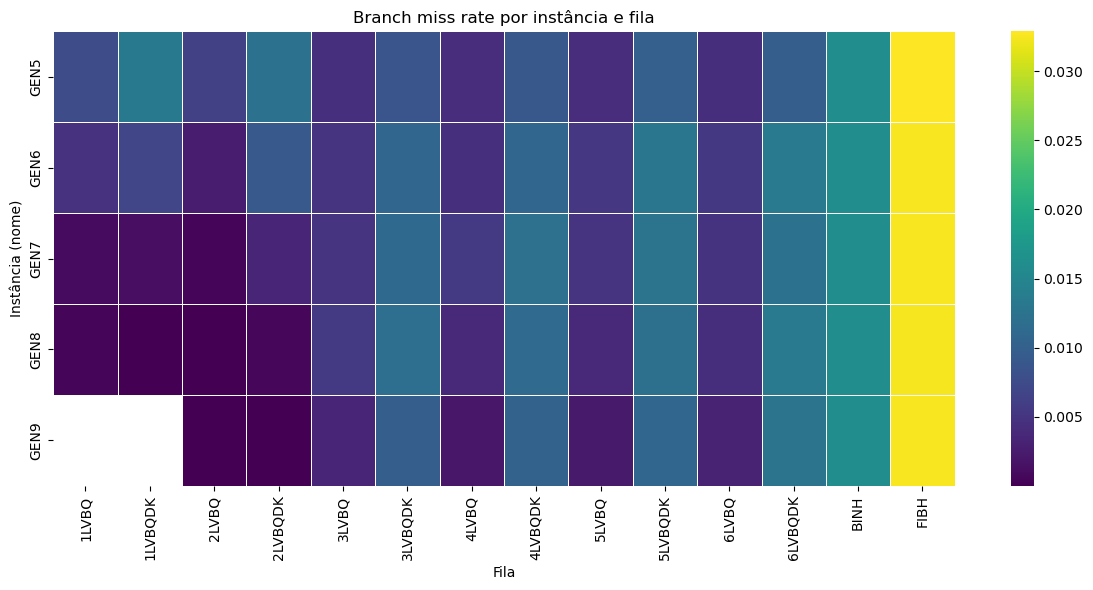

In [170]:

# ===== métrica escolhida =====
df_plot = df_branches.copy()

# opção A: LLC apenas
df_plot["miss"] = df_plot["bm_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="bm_mean")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Branch miss rate por instância e fila")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()